# DDoS Detection using Machine Learning

Notebook nay duoc sap xep theo phong cach Kaggle: load data, EDA,
cleaning, preprocessing, train/test split, train model, evaluate,
compare model va save best model.

Luu y ky thuat: preprocessing duoc dat ben trong `sklearn Pipeline`, vi
vay imputer, scaler, encoder va correlation filter chi duoc fit tren
training split, khong fit tren toan bo dataset truoc khi chia du lieu.

## 0. Environment and project paths

In [1]:
from pathlib import Path
import os
import pickle
import re
import sys
import time
import warnings

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r"D:\source\CyRadar\VBoxShare\mlddos"),
    Path("/mnt/d/source/CyRadar/VBoxShare/mlddos"),
]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "backend" / "src").exists()),
    Path.cwd(),
)
BACKEND_SRC = PROJECT_ROOT / "backend" / "src"
if str(BACKEND_SRC) not in sys.path:
    sys.path.insert(0, str(BACKEND_SRC))

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "saved_models"
for directory in [DATA_DIR, RESULTS_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore", category=FutureWarning)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Results dir:", RESULTS_DIR)
print("Models dir:", MODELS_DIR)

Project root: D:\source\CyRadar\VBoxShare\mlddos
Data dir: D:\source\CyRadar\VBoxShare\mlddos\data
Results dir: D:\source\CyRadar\VBoxShare\mlddos\results
Models dir: D:\source\CyRadar\VBoxShare\mlddos\saved_models


## 1. Import libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

from ml_ddos.data_loader import (
    KAGGLE_DATASET_SLUG,
    collect_file_paths,
    load_dataset,
)
from ml_ddos.models import (
    CappedUnderSamplingStrategy,
    LEAKAGE_COLUMN_PATTERNS,
    TrafficFeaturePreprocessor,
    TrainingConfig,
    fit_xgb_with_early_stopping,
)
from ml_ddos.preprocessor import TARGET_COL, harmonize_labels, remove_duplicates

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

## 2. Notebook configuration

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 3
CORRELATION_THRESHOLD = 0.90
HIGH_CORRELATION_WARNING = 0.95
NEAR_CONSTANT_UNIQUE_PERCENT = 1.0

SAMPLE_MODE = True
EDA_SAMPLE_SIZE = 15000
OUTLIER_SAMPLE_SIZE = 6000

# Keep this notebook fast enough to run interactively.
# Set MAX_TRAIN_ROWS_PER_BINARY_CLASS = None to use every available
# balanced training row. The external testing files are kept separate
# and are never mixed into training.
MAX_TRAIN_ROWS_PER_BINARY_CLASS = 12000

MODEL_OUTPUT_PATH = MODELS_DIR / "notebook_best_binary_model.pkl"
COMPARISON_OUTPUT_PATH = RESULTS_DIR / "notebook_model_comparison.csv"
REPORT_OUTPUT_PATH = RESULTS_DIR / "notebook_best_model_report.txt"

print("Dataset:", KAGGLE_DATASET_SLUG)
print("Target column:", TARGET_COL)
print("Test size:", TEST_SIZE)
print("CV folds:", CV_FOLDS)
print("Max training rows per binary class:", MAX_TRAIN_ROWS_PER_BINARY_CLASS)
print("Sample mode for heavy EDA:", SAMPLE_MODE)
print("EDA sample size:", EDA_SAMPLE_SIZE)
print("Outlier sample size:", OUTLIER_SAMPLE_SIZE)

Dataset: dhoogla/cicddos2019
Target column: Label
Test size: 0.2
CV folds: 3
Max training rows per binary class: 12000
Sample mode for heavy EDA: True
EDA sample size: 15000
Outlier sample size: 6000


## 3. Dataset files

In [4]:
train_paths, test_paths = collect_file_paths(str(DATA_DIR))

file_overview = pd.DataFrame(
    {
        "split": ["training"] * len(train_paths) + ["testing"] * len(test_paths),
        "file_name": [Path(p).name for p in train_paths + test_paths],
        "size_mb": [Path(p).stat().st_size / (1024 * 1024) for p in train_paths + test_paths],
    }
)
display(file_overview)

[data_loader] Found 7 training files, 10 testing files.


,split,file_name,size_mb
0,training,LDAP-training.parquet,0.591091
1,training,MSSQL-training.parquet,0.554406
2,training,NetBIOS-training.parquet,0.212893
3,training,Portmap-training.parquet,0.544459
4,training,Syn-training.parquet,8.209293
5,training,UDP-training.parquet,1.320803
6,training,UDPLag-training.parquet,1.363326
7,testing,DNS-testing.parquet,0.487164
8,testing,LDAP-testing.parquet,0.213963
9,testing,MSSQL-testing.parquet,0.402324


## 4. Load raw dataset

In [5]:
train_raw, test_raw = load_dataset(str(DATA_DIR))

print("Raw train shape:", train_raw.shape)
print("Raw test shape:", test_raw.shape)
display(train_raw.head())
display(test_raw.head())

[data_loader] Dataset already present (17 files). Skipping download.
[data_loader] Found 7 training files, 10 testing files.
[data_loader] Common attack types: ['LDAP', 'MSSQL', 'NetBIOS', 'Syn', 'UDP', 'UDPLag']
[data_loader] Loading training data ...


Train files: 100%|███████████████████████████████| 6/6 [00:00<00:00, 16.19it/s]


[data_loader] Loading testing data ...


Test files: 100%|████████████████████████████████| 6/6 [00:00<00:00, 28.35it/s]


[data_loader] Train shape: (120065, 78), Test shape: (38973, 78)
Raw train shape: (120065, 78)
Raw test shape: (38973, 78)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Avg Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init Fwd Win Bytes,Init Bwd Win Bytes,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,49,2,0,458.0,0.0,229.0,229.0,229.0,0.0,0.0,0.0,0.0,0.0,9.346939e+06,4.081633e+04,49.0,0.0,49.0,49.0,49.0,49.0,0.0,49.0,49.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,16,0,4.081633e+04,0.0,229.0,229.0,229.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,343.5,229.0,0.0,0,0,0,0,0,0,2,458,0,0,-1,-1,1,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NetBIOS
1,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0.0,0.0,0.0,2.944000e+09,2.000000e+06,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,2960,0,2.000000e+06,0.0,1472.0,1472.0,1472.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2208.0,1472.0,0.0,0,0,0,0,0,0,2,2944,0,0,-1,-1,1,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP
2,17,1,2,0,458.0,0.0,229.0,229.0,229.0,0.0,0.0,0.0,0.0,0.0,4.580000e+08,2.000000e+06,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,28,0,2.000000e+06,0.0,229.0,229.0,229.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,343.5,229.0,0.0,0,0,0,0,0,0,2,458,0,0,-1,-1,1,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NetBIOS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0.0,0.0,0.0,2.944000e+09,2.000000e+06,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,28,0,2.000000e+06,0.0,1472.0,1472.0,1472.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2208.0,1472.0,0.0,0,0,0,0,0,0,2,2944,0,0,-1,-1,1,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP
4,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0.0,0.0,0.0,2.944000e+09,2.000000e+06,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,64,0,2.000000e+06,0.0,1472.0,1472.0,1472.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2208.0,1472.0,0.0,0,0,0,0,0,0,2,2944,0,0,-1,-1,1,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Avg Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init Fwd Win Bytes,Init Bwd Win Bytes,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0.0,0.0,0.0,2.944000e+09,2000000.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,2000000.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2208.0,1472.0,0.0,0,0,0,0,0,0,2,2944,0,0,-1,-1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_LDAP
1,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0.0,0.0,0.0,2.944000e+09,2000000.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,2944,0,2000000.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2208.0,1472.0,0.0,0,0,0,0,0,0,2,2944,0,0,-1,-1,1,1472,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_LDAP
2,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0.0,0.0,0.0,2.944000e+09,2000000.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,40,0,2000000.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2208.0,1472.0,0.0,0,0,0,0,0,0,2,2944,0,0,-1,-1,1,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_LDAP
3,17,2,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0.0,0.0,0.0,1.472000e+09,1000000.0,2.0,0.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,-2,0,1000000.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2208.0,1472.0,0.0,0,0,0,0,0,0,2,2944,0,0,-1,-1,1,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_LDAP
4,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0.0,0.0,0.0,2.944000e+09,2000000.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,28,0,2000000.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2208.0,1472.0,0.0,0,0,0,0,0,0,2,2944,0,0,-1,-1,1,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_LDAP


## 5. Dataset Overview

In [6]:
def count_infinite_values(df: pd.DataFrame) -> int:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) == 0:
        return 0
    return int(np.isinf(df[numeric_cols]).sum().sum())


dataset_overview = pd.DataFrame(
    [
        {
            "split": "raw_train",
            "rows": len(train_raw),
            "columns": train_raw.shape[1],
            "memory_mb": train_raw.memory_usage(deep=True).sum() / (1024**2),
            "duplicate_rows": int(train_raw.duplicated().sum()),
            "missing_values": int(train_raw.isna().sum().sum()),
            "infinite_values": count_infinite_values(train_raw),
        },
        {
            "split": "raw_test",
            "rows": len(test_raw),
            "columns": test_raw.shape[1],
            "memory_mb": test_raw.memory_usage(deep=True).sum() / (1024**2),
            "duplicate_rows": int(test_raw.duplicated().sum()),
            "missing_values": int(test_raw.isna().sum().sum()),
            "infinite_values": count_infinite_values(test_raw),
        },
    ]
)
display(dataset_overview)
dataset_overview.to_csv(RESULTS_DIR / "notebook_dataset_overview.csv", index=False)

column_overview = pd.DataFrame(
    {
        "column": train_raw.columns,
        "dtype": [str(dtype) for dtype in train_raw.dtypes],
        "train_missing": train_raw.isna().sum().to_numpy(),
        "test_missing": test_raw.isna().sum().reindex(train_raw.columns, fill_value=np.nan).to_numpy(),
        "train_unique": train_raw.nunique(dropna=False).to_numpy(),
    }
)
display(column_overview)
column_overview.to_csv(RESULTS_DIR / "notebook_column_overview.csv", index=False)

display(pd.DataFrame({"train_dtype": train_raw.dtypes.astype(str).value_counts()}))
display(train_raw[TARGET_COL].value_counts().rename_axis("label").reset_index(name="train_count"))
display(test_raw[TARGET_COL].value_counts().rename_axis("label").reset_index(name="test_count"))

,split,rows,columns,memory_mb,duplicate_rows,missing_values,infinite_values
0,raw_train,120065,78,36.896430,3195,0,0
1,raw_test,38973,78,11.783807,242,0,0


,column,dtype,train_missing,test_missing,train_unique
0,Protocol,int8,0,0,3
1,Flow Duration,int32,0,0,74239
2,Total Fwd Packets,int32,0,0,294
3,Total Backward Packets,int16,0,0,386
4,Fwd Packets Length Total,float32,0,0,3832
...,...,...,...,...,...
73,Idle Mean,float32,0,0,45309
74,Idle Std,float32,0,0,40894
75,Idle Max,float32,0,0,45071
76,Idle Min,float32,0,0,44888


,train_dtype
float32,43
int8,19
int32,8
int16,3
float64,2
int64,2
object,1


,label,train_count
0,Syn,48840
1,Benign,42007
2,UDP,18090
3,MSSQL,8523
4,LDAP,1906
5,NetBIOS,644
6,UDPLag,55


,label,test_count
0,Benign,10847
1,DrDoS_UDP,10420
2,UDP-lag,8872
3,DrDoS_MSSQL,6212
4,DrDoS_LDAP,1440
5,DrDoS_NetBIOS,598
6,Syn,533
7,WebDDoS,51


## 6. Cleaning and Label Harmonization

In [7]:
train_h, test_h = harmonize_labels(train_raw, test_raw)

before_train, before_test = len(train_h), len(test_h)
train_clean = remove_duplicates(train_h, "notebook training data")
test_clean = remove_duplicates(test_h, "notebook testing data")

print("Train rows before duplicate removal:", before_train)
print("Test rows before duplicate removal:", before_test)
print("Train rows after duplicate removal:", len(train_clean))
print("Test rows after duplicate removal:", len(test_clean))

harmonized_distribution = pd.DataFrame(
    {
        "train_clean": train_clean[TARGET_COL].value_counts(),
        "test_clean": test_clean[TARGET_COL].value_counts(),
    }
).fillna(0).astype(int)
display(harmonized_distribution)

[preprocessor] Removing test-only labels (not in train): {'WebDDoS'}
[preprocessor] Labels harmonized. Train classes: ['Benign', 'LDAP Flood', 'MSSQL Flood', 'NetBIOS Flood', 'TCP SYN Flood', 'UDP Flood', 'UDP-Lag Flood']
[preprocessor] Removed 3,195 duplicate rows from notebook training data.
[preprocessor] Removed 242 duplicate rows from notebook testing data.
Train rows before duplicate removal: 120065
Test rows before duplicate removal: 38922
Train rows after duplicate removal: 116870
Test rows after duplicate removal: 38680


,train_clean,test_clean
Label,,
Benign,40980,10605
LDAP Flood,1885,1440
MSSQL Flood,8434,6212
NetBIOS Flood,475,598
TCP SYN Flood,47246,533
UDP Flood,17795,10420
UDP-Lag Flood,55,8872


## 7. Data Quality Check

In [8]:
def build_feature_quality_table(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    rows = []
    n_rows = len(df)
    numeric_cols = set(df.select_dtypes(include=[np.number]).columns)
    for col in df.columns:
        series = df[col]
        row = {
            "feature": col,
            "dtype": str(series.dtype),
            "missing_count": int(series.isna().sum()),
            "missing_percent": float(series.isna().mean() * 100),
            "unique_count": int(series.nunique(dropna=False)),
            "unique_percent": float(series.nunique(dropna=False) / max(n_rows, 1) * 100),
            "is_target": col == target_col,
        }
        if col in numeric_cols:
            numeric = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
            row.update(
                {
                    "min": float(numeric.min()) if numeric.notna().any() else np.nan,
                    "max": float(numeric.max()) if numeric.notna().any() else np.nan,
                    "mean": float(numeric.mean()) if numeric.notna().any() else np.nan,
                    "median": float(numeric.median()) if numeric.notna().any() else np.nan,
                    "std": float(numeric.std()) if numeric.notna().any() else np.nan,
                }
            )
        else:
            row.update({"min": np.nan, "max": np.nan, "mean": np.nan, "median": np.nan, "std": np.nan})
        rows.append(row)
    return pd.DataFrame(rows)


def find_configured_leakage_columns(columns):
    detected = []
    for col in columns:
        normalized = re.sub(r"[_\-]+", " ", str(col).strip().lower())
        if any(re.search(pattern, normalized) for pattern in LEAKAGE_COLUMN_PATTERNS):
            detected.append(col)
    return detected


feature_quality_df = build_feature_quality_table(train_clean, TARGET_COL)
display(feature_quality_df)
feature_quality_df.to_csv(RESULTS_DIR / "notebook_feature_quality.csv", index=False)

constant_features = feature_quality_df[
    (~feature_quality_df["is_target"]) & (feature_quality_df["unique_count"] <= 1)
][["feature", "dtype", "unique_count"]]
near_constant_features = feature_quality_df[
    (~feature_quality_df["is_target"])
    & (feature_quality_df["unique_count"] > 1)
    & (feature_quality_df["unique_percent"] <= NEAR_CONSTANT_UNIQUE_PERCENT)
][["feature", "dtype", "unique_count", "unique_percent"]]
high_unique_features = feature_quality_df[
    (~feature_quality_df["is_target"])
    & (
        (feature_quality_df["unique_percent"] >= 80)
        | (feature_quality_df["unique_count"] >= 10000)
    )
][["feature", "dtype", "unique_count", "unique_percent"]]

leakage_like_features = pd.DataFrame(
    {
        "feature": find_configured_leakage_columns(feature_quality_df["feature"]),
    }
)

display(constant_features)
display(near_constant_features)
display(high_unique_features.head(30))
display(leakage_like_features)

constant_features.to_csv(RESULTS_DIR / "notebook_constant_features.csv", index=False)
near_constant_features.to_csv(RESULTS_DIR / "notebook_near_constant_features.csv", index=False)
high_unique_features.to_csv(RESULTS_DIR / "notebook_high_unique_features.csv", index=False)
leakage_like_features.to_csv(RESULTS_DIR / "notebook_leakage_like_features.csv", index=False)

,feature,dtype,missing_count,missing_percent,unique_count,unique_percent,is_target,min,max,mean,median,std
0,Protocol,int8,0,0.0,3,0.002567,False,0.0,17.0,9.897313e+00,6.0,5.321783e+00
1,Flow Duration,int32,0,0.0,74239,63.522718,False,1.0,119997515.0,2.108720e+07,211191.5,3.016681e+07
2,Total Fwd Packets,int32,0,0.0,294,0.251562,False,1.0,86666.0,9.697664e+00,4.0,3.611523e+02
3,Total Backward Packets,int16,0,0.0,386,0.330282,False,0.0,8029.0,5.344374e+00,2.0,4.717026e+01
4,Fwd Packets Length Total,float32,0,0.0,3832,3.278857,False,0.0,208524.0,8.104947e+02,72.0,2.808176e+03
...,...,...,...,...,...,...,...,...,...,...,...,...
73,Idle Mean,float32,0,0.0,45309,38.768717,False,0.0,117569200.0,6.435402e+06,0.0,1.062835e+07
74,Idle Std,float32,0,0.0,40894,34.991016,False,0.0,69614024.0,1.602638e+06,0.0,3.223407e+06
75,Idle Max,float32,0,0.0,45071,38.565072,False,0.0,117569200.0,8.149503e+06,0.0,1.253573e+07
76,Idle Min,float32,0,0.0,44888,38.408488,False,0.0,117569200.0,4.945397e+06,0.0,9.584982e+06


,feature,dtype,unique_count
31,Bwd PSH Flags,int8,1
32,Fwd URG Flags,int8,1
33,Bwd URG Flags,int8,1
43,FIN Flag Count,int8,1
46,PSH Flag Count,int8,1
50,ECE Flag Count,int8,1
55,Fwd Avg Bytes/Bulk,int8,1
56,Fwd Avg Packets/Bulk,int8,1
57,Fwd Avg Bulk Rate,int8,1
58,Bwd Avg Bytes/Bulk,int8,1


,feature,dtype,unique_count,unique_percent
0,Protocol,int8,3,0.002567
2,Total Fwd Packets,int32,294,0.251562
3,Total Backward Packets,int16,386,0.330282
7,Fwd Packet Length Min,float32,662,0.566441
10,Bwd Packet Length Max,float32,1028,0.879610
11,Bwd Packet Length Min,float32,210,0.179687
24,Fwd IAT Min,float32,424,0.362796
29,Bwd IAT Min,float32,104,0.088988
30,Fwd PSH Flags,int8,2,0.001711
35,Bwd Header Length,int64,875,0.748695


,feature,dtype,unique_count,unique_percent
1,Flow Duration,int32,74239,63.522718
14,Flow Bytes/s,float64,84113,71.971421
15,Flow Packets/s,float64,75768,64.831009
16,Flow IAT Mean,float32,75605,64.691538
17,Flow IAT Std,float32,83099,71.103791
18,Flow IAT Max,float32,70468,60.296055
20,Fwd IAT Total,float32,64228,54.956790
21,Fwd IAT Mean,float32,64859,55.496706
22,Fwd IAT Std,float32,69801,59.725336
23,Fwd IAT Max,float32,60232,51.537606


,feature
0,Label


## 8. Outlier Detection Summary

,selected_feature,variance
0,Flow Bytes/s,1.492155e+17
1,Fwd Header Length,8.575097e+16
2,Fwd Seg Size Min,1.419850e+16
3,Bwd Header Length,6.700509e+15
4,Fwd IAT Total,8.985295e+14
5,Flow Duration,8.961670e+14
6,Bwd IAT Total,5.388699e+14
7,Bwd IAT Max,1.858000e+14
8,Idle Max,1.551359e+14
9,Flow IAT Max,1.537063e+14


,method,sample_rows,outlier_rows,outlier_percent
0,IQR,15000,10766,71.773333
1,Z-score > 3,15000,1848,12.320000
2,Isolation Forest,6000,647,10.783333


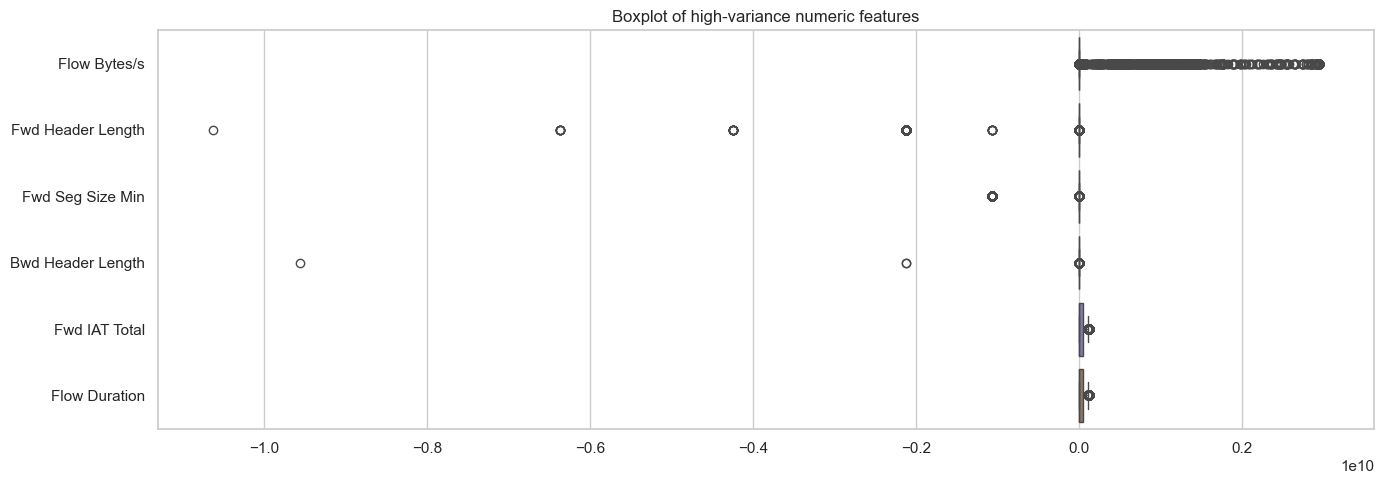

Outliers are reported only. They are not removed before model training.
If capping/removal is needed, fit thresholds on X_train only and apply them inside the pipeline.


In [9]:
train_eda = train_clean.copy()
train_eda["binary_label"] = np.where(train_eda[TARGET_COL].eq("Benign"), "Benign", "Attack")
if SAMPLE_MODE and len(train_eda) > EDA_SAMPLE_SIZE:
    train_eda_sample = train_eda.sample(n=EDA_SAMPLE_SIZE, random_state=RANDOM_STATE)
else:
    train_eda_sample = train_eda.copy()

numeric_features = [
    col for col in train_eda_sample.select_dtypes(include=[np.number]).columns
    if col != TARGET_COL
]
numeric_for_eda = train_eda_sample[numeric_features].replace([np.inf, -np.inf], np.nan)
numeric_for_eda = numeric_for_eda.apply(pd.to_numeric, errors="coerce")

variances = numeric_for_eda.var(numeric_only=True).sort_values(ascending=False)
important_numeric_features = variances.head(20).index.tolist()
display(pd.DataFrame({"selected_feature": important_numeric_features, "variance": variances.head(20).values}))

outlier_base = numeric_for_eda[important_numeric_features].copy()
outlier_base = outlier_base.fillna(outlier_base.median(numeric_only=True)).fillna(0)

q1 = outlier_base.quantile(0.25)
q3 = outlier_base.quantile(0.75)
iqr = q3 - q1
iqr_mask = ((outlier_base < (q1 - 1.5 * iqr)) | (outlier_base > (q3 + 1.5 * iqr))).any(axis=1)

std = outlier_base.std(ddof=0).replace(0, np.nan)
z_scores = ((outlier_base - outlier_base.mean()) / std).abs().fillna(0)
z_mask = (z_scores > 3).any(axis=1)

outlier_sample_size = min(len(outlier_base), OUTLIER_SAMPLE_SIZE)
outlier_sample = outlier_base.sample(n=outlier_sample_size, random_state=RANDOM_STATE)
scaled_outlier_sample = StandardScaler().fit_transform(outlier_sample)

iso = IsolationForest(contamination="auto", random_state=RANDOM_STATE, n_jobs=-1)
iso_pred = iso.fit_predict(scaled_outlier_sample)
iso_outlier_count = int((iso_pred == -1).sum())

outlier_summary = pd.DataFrame(
    [
        {"method": "IQR", "sample_rows": len(outlier_base), "outlier_rows": int(iqr_mask.sum())},
        {"method": "Z-score > 3", "sample_rows": len(outlier_base), "outlier_rows": int(z_mask.sum())},
        {"method": "Isolation Forest", "sample_rows": outlier_sample_size, "outlier_rows": iso_outlier_count},
    ]
)
outlier_summary["outlier_percent"] = (
    outlier_summary["outlier_rows"] / outlier_summary["sample_rows"] * 100
)
display(outlier_summary)
outlier_summary.to_csv(RESULTS_DIR / "notebook_outlier_summary.csv", index=False)

boxplot_features = important_numeric_features[:6]
if boxplot_features:
    plt.figure(figsize=(14, 5))
    sns.boxplot(data=outlier_base[boxplot_features], orient="h")
    plt.title("Boxplot of high-variance numeric features")
    plt.tight_layout()
    plt.show()

print("Outliers are reported only. They are not removed before model training.")
print("If capping/removal is needed, fit thresholds on X_train only and apply them inside the pipeline.")

## 9. Feature Distribution Analysis

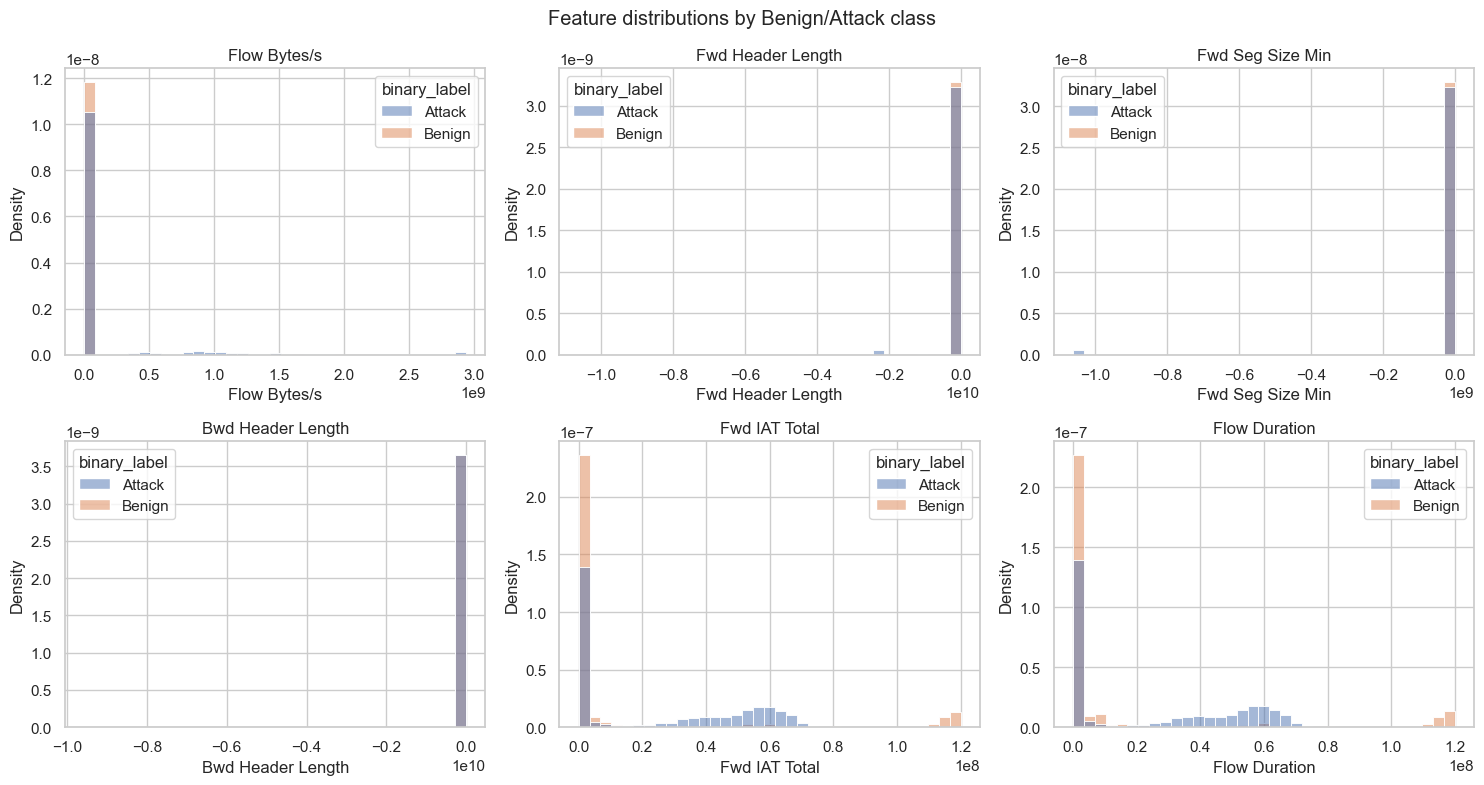

,feature,status
0,Flow Bytes/s,plotted
1,Fwd Header Length,plotted
2,Fwd Seg Size Min,plotted
3,Bwd Header Length,plotted
4,Fwd IAT Total,plotted
5,Flow Duration,plotted


In [10]:
distribution_features = important_numeric_features[:6]
distribution_rows = []
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
plotted = 0
for feature in distribution_features:
    plot_df = train_eda_sample[[feature, "binary_label"]].replace([np.inf, -np.inf], np.nan).dropna()
    if plot_df[feature].nunique(dropna=True) <= 1:
        distribution_rows.append({"feature": feature, "status": "skipped_not_enough_unique_values"})
        continue
    sns.histplot(
        data=plot_df,
        x=feature,
        hue="binary_label",
        bins=35,
        stat="density",
        common_norm=False,
        ax=axes[plotted],
    )
    axes[plotted].set_title(feature)
    distribution_rows.append({"feature": feature, "status": "plotted"})
    plotted += 1
    if plotted >= len(axes):
        break
for ax in axes[plotted:]:
    ax.axis("off")
plt.suptitle("Feature distributions by Benign/Attack class")
plt.tight_layout()
plt.show()

distribution_summary = pd.DataFrame(distribution_rows)
display(distribution_summary)
distribution_summary.to_csv(RESULTS_DIR / "notebook_distribution_plot_summary.csv", index=False)

## 10. Correlation Analysis

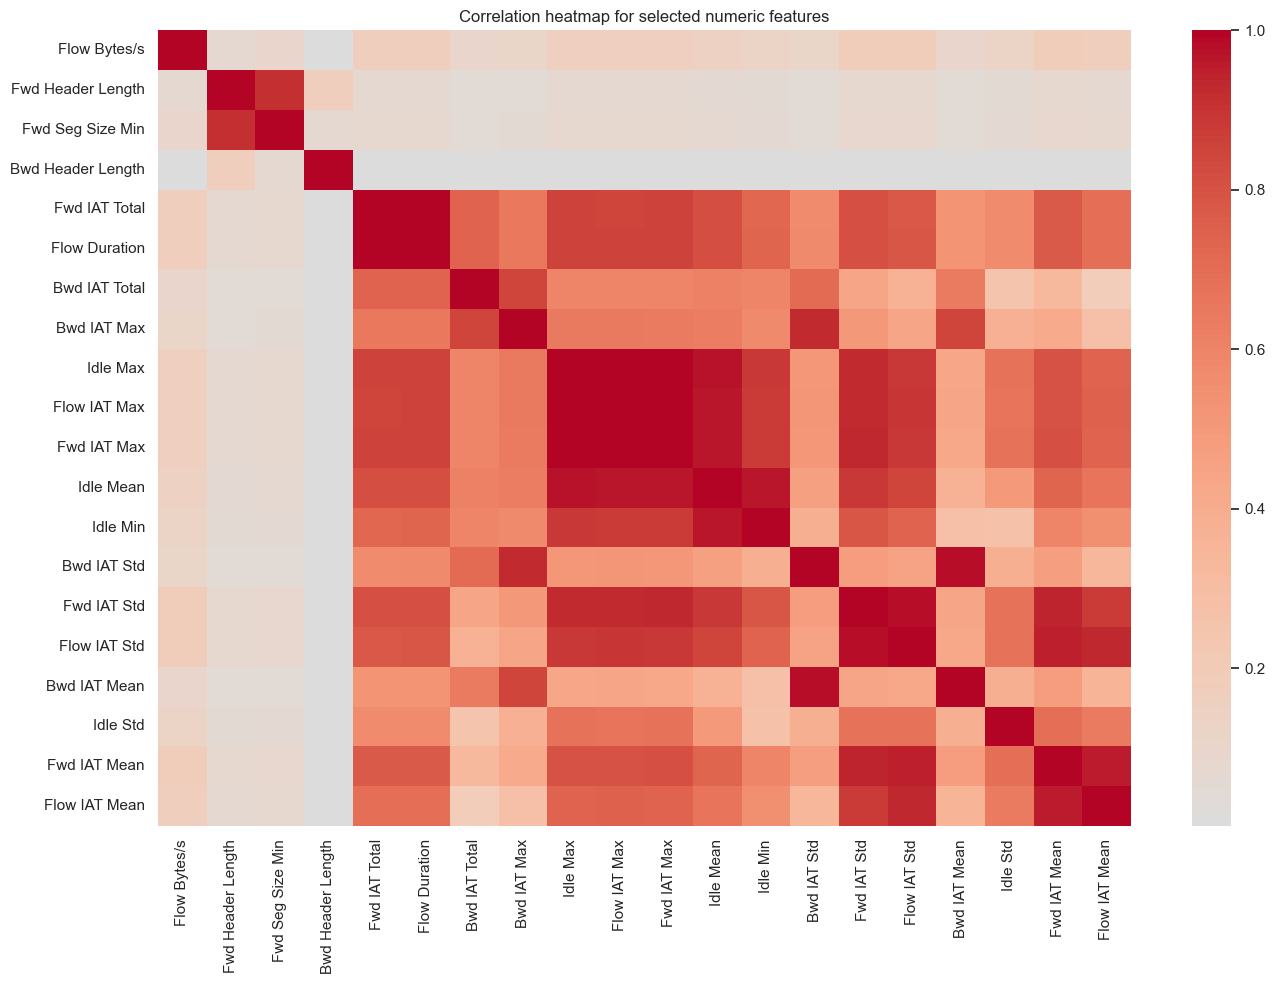

,feature_1,feature_2,correlation
0,Total Fwd Packets,Subflow Fwd Packets,1.000000
1,Total Backward Packets,Subflow Bwd Packets,1.000000
2,Fwd Packets Length Total,Subflow Fwd Bytes,1.000000
3,Fwd PSH Flags,RST Flag Count,1.000000
4,Bwd Packets Length Total,Subflow Bwd Bytes,1.000000
5,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000
6,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000
7,Flow IAT Min,Fwd IAT Min,0.999078
8,Flow Duration,Fwd IAT Total,0.998762
9,Flow Packets/s,Fwd Packets/s,0.995728


The target label is not included in the correlation matrix.
High-correlation features are not manually deleted here; TrafficFeaturePreprocessor removes them using train-only fit.


In [11]:
corr_features = important_numeric_features[:20]
corr_matrix = numeric_for_eda[corr_features].replace([np.inf, -np.inf], np.nan)
corr_matrix = corr_matrix.fillna(corr_matrix.median(numeric_only=True)).fillna(0).corr().abs()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=False)
plt.title("Correlation heatmap for selected numeric features")
plt.tight_layout()
plt.show()

full_corr = numeric_for_eda.fillna(numeric_for_eda.median(numeric_only=True)).fillna(0).corr().abs()
upper_mask = np.triu(np.ones(full_corr.shape), k=1).astype(bool)
upper_corr = full_corr.where(upper_mask)
high_corr_pairs = (
    upper_corr.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
    .query("correlation >= @HIGH_CORRELATION_WARNING")
    .sort_values("correlation", ascending=False)
    .reset_index(drop=True)
)
display(high_corr_pairs.head(50))
high_corr_pairs.to_csv(RESULTS_DIR / "notebook_high_correlation_pairs.csv", index=False)

print("The target label is not included in the correlation matrix.")
print("High-correlation features are not manually deleted here; TrafficFeaturePreprocessor removes them using train-only fit.")

## 11. Class Imbalance Analysis

,class,count,percent
0,TCP SYN Flood,47246,40.426114
1,Benign,40980,35.064602
2,UDP Flood,17795,15.226320
3,MSSQL Flood,8434,7.216565
4,LDAP Flood,1885,1.612903
5,NetBIOS Flood,475,0.406434
6,UDP-Lag Flood,55,0.047061


Multiclass imbalance ratio: 859.0182


,binary_class,count,percent
0,Attack,75890,64.935398
1,Benign,40980,35.064602


Binary class imbalance ratio: 1.8519


,class,count,percent
5,NetBIOS Flood,475,0.406434
6,UDP-Lag Flood,55,0.047061


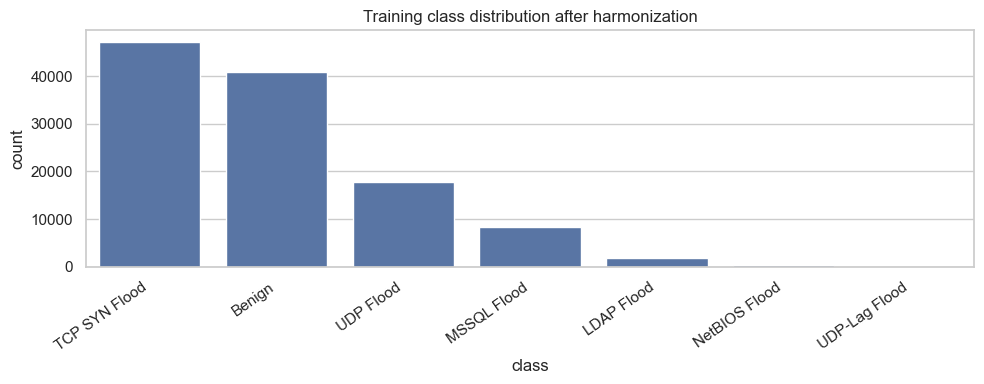

,method,leakage_safe_usage
0,class_weight,Set on model; uses train labels only.
1,SMOTE,Apply inside imblearn Pipeline after train/tes...
2,undersampling,Apply on training split only; test distributio...
3,oversampling,Apply on training split only; never before spl...
4,XGBoost binary scale_pos_weight,Use only for binary mode; for multiclass use s...


In [12]:
multiclass_counts = train_clean[TARGET_COL].value_counts().rename_axis("class").reset_index(name="count")
multiclass_counts["percent"] = multiclass_counts["count"] / multiclass_counts["count"].sum() * 100
multiclass_imbalance_ratio = float(multiclass_counts["count"].max() / multiclass_counts["count"].min())
display(multiclass_counts)
print("Multiclass imbalance ratio:", round(multiclass_imbalance_ratio, 4))

binary_counts_train = train_eda["binary_label"].value_counts().rename_axis("binary_class").reset_index(name="count")
binary_counts_train["percent"] = binary_counts_train["count"] / binary_counts_train["count"].sum() * 100
class_imbalance_ratio = float(binary_counts_train["count"].max() / binary_counts_train["count"].min())
display(binary_counts_train)
print("Binary class imbalance ratio:", round(class_imbalance_ratio, 4))

rare_class_warning_df = multiclass_counts[multiclass_counts["count"] < 1000].copy()
if not rare_class_warning_df.empty:
    print("WARNING: Some multiclass labels have fewer than 1,000 training rows.")
    display(rare_class_warning_df)

plt.figure(figsize=(10, 4))
sns.barplot(data=multiclass_counts, x="class", y="count")
plt.title("Training class distribution after harmonization")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

imbalance_options = pd.DataFrame(
    [
        {"method": "class_weight", "leakage_safe_usage": "Set on model; uses train labels only."},
        {"method": "SMOTE", "leakage_safe_usage": "Apply inside imblearn Pipeline after train/test split only."},
        {"method": "undersampling", "leakage_safe_usage": "Apply on training split only; test distribution remains untouched."},
        {"method": "oversampling", "leakage_safe_usage": "Apply on training split only; never before splitting."},
        {"method": "XGBoost binary scale_pos_weight", "leakage_safe_usage": "Use only for binary mode; for multiclass use sample_weight from train labels."},
    ]
)
display(imbalance_options)
multiclass_counts.to_csv(RESULTS_DIR / "notebook_multiclass_distribution.csv", index=False)
binary_counts_train.to_csv(RESULTS_DIR / "notebook_binary_distribution_train_source.csv", index=False)

## 12. Stratified Multiclass Train/Test Split

In [13]:
# Audit the official source train/test files first. The CICDDoS2019
# parquet split can have strong source distribution shift; for example,
# UDP-Lag may be tiny in source train but large in source test.
source_multiclass_distribution = pd.DataFrame(
    {
        "source_train": train_clean[TARGET_COL].value_counts(),
        "source_test": test_clean[TARGET_COL].value_counts(),
    }
).fillna(0).astype(int)
source_multiclass_distribution["source_train_percent"] = (
    source_multiclass_distribution["source_train"] / source_multiclass_distribution["source_train"].sum() * 100
).round(2)
source_multiclass_distribution["source_test_percent"] = (
    source_multiclass_distribution["source_test"] / source_multiclass_distribution["source_test"].sum() * 100
).round(2)
display(source_multiclass_distribution)
source_multiclass_distribution.to_csv(RESULTS_DIR / "notebook_source_multiclass_distribution.csv")

source_shift_rows = source_multiclass_distribution[
    (source_multiclass_distribution["source_train"] < 100)
    & (source_multiclass_distribution["source_test"] > 1000)
]
if not source_shift_rows.empty:
    print("WARNING: Official source train/test split has severe class distribution shift.")
    display(source_shift_rows)

# Main benchmark split: combine harmonized source files, remove exact
# duplicate rows globally, then split with stratify=y. This makes
# train/test counts consistent with the actual dataset distribution and
# avoids the misleading source-split issue above.
combined_multiclass_raw = pd.concat([train_clean, test_clean], ignore_index=True)
combined_rows_before_global_dedup = len(combined_multiclass_raw)
combined_multiclass = remove_duplicates(combined_multiclass_raw, "combined multiclass data")
combined_rows_after_global_dedup = len(combined_multiclass)
removed_global_duplicates = combined_rows_before_global_dedup - combined_rows_after_global_dedup

original_class_distribution = combined_multiclass[TARGET_COL].value_counts().rename_axis("class").reset_index(name="count")
original_class_distribution["percent"] = original_class_distribution["count"] / original_class_distribution["count"].sum() * 100
display(original_class_distribution)
original_class_distribution.to_csv(RESULTS_DIR / "notebook_original_class_distribution_before_split.csv", index=False)

original_class_distribution_normalized = combined_multiclass[TARGET_COL].value_counts(normalize=True).rename_axis("class").reset_index(name="ratio")
display(original_class_distribution_normalized)
original_class_distribution_normalized.to_csv(RESULTS_DIR / "notebook_original_class_distribution_ratio_before_split.csv", index=False)

X_all = combined_multiclass.drop(columns=[TARGET_COL])
y_all_text = combined_multiclass[TARGET_COL].astype(str)
X_train, X_test, y_train_text, y_test_text = train_test_split(
    X_all,
    y_all_text,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_all_text,
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train_text = y_train_text.reset_index(drop=True)
y_test_text = y_test_text.reset_index(drop=True)

removed_cross_source_duplicates = 0

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_text)
y_test = label_encoder.transform(y_test_text)
class_names = list(label_encoder.classes_)
label_mapping_df = pd.DataFrame(
    {
        "encoded_label": list(range(len(label_encoder.classes_))),
        "original_label": label_encoder.classes_,
    }
)
display(label_mapping_df)
label_mapping_df.to_csv(RESULTS_DIR / "notebook_label_encoder_mapping.csv", index=False)

class_counts_train = pd.Series(y_train_text).value_counts()
minority_class_names = class_counts_train[class_counts_train < 1000].index.tolist()
minority_class_indices = [int(np.where(label_encoder.classes_ == name)[0][0]) for name in minority_class_names]
if not minority_class_names:
    minority_class_names = [class_counts_train.idxmin()]
    minority_class_indices = [int(np.where(label_encoder.classes_ == minority_class_names[0])[0][0])]

split_distribution = pd.DataFrame(
    {
        "train": y_train_text.value_counts(),
        "test": y_test_text.value_counts(),
    }
).fillna(0).astype(int)
split_distribution["train_percent"] = (
    split_distribution["train"] / split_distribution["train"].sum() * 100
).round(2)
split_distribution["test_percent"] = (
    split_distribution["test"] / split_distribution["test"].sum() * 100
).round(2)

print("Class names:", class_names)
print("Minority classes for recall tracking:", minority_class_names)
print("X_train:", X_train.shape, "X_test:", X_test.shape)
display(split_distribution)
split_distribution["train_plus_test"] = split_distribution["train"] + split_distribution["test"]
split_integrity_df = original_class_distribution.set_index("class")[["count"]].join(
    split_distribution[["train_plus_test"]],
    how="left",
)
split_integrity_df["matches_original"] = split_integrity_df["count"].eq(split_integrity_df["train_plus_test"])
display(split_integrity_df)
split_distribution.to_csv(RESULTS_DIR / "notebook_stratified_split_distribution.csv")
split_integrity_df.to_csv(RESULTS_DIR / "notebook_split_integrity_check.csv")

if not split_integrity_df["matches_original"].all():
    raise ValueError("Train/test split integrity check failed: train + test counts do not match original distribution.")

rare_split_warning = split_distribution[
    (split_distribution["train"] < 100) | (split_distribution["test"] < 100)
].copy()
if not rare_split_warning.empty:
    print("WARNING: Some classes have very few rows in train/test; metrics for these classes may be unstable.")
    display(rare_split_warning)

# Stratified split audit required for model validation / early stopping.
# The external source test remains untouched; this split proves that any
# internal validation split preserves class proportions.
_, stratified_audit_y = train_test_split(
    y_train,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train,
)
stratified_audit = pd.DataFrame(
    {
        "class": class_names,
        "train_count": np.bincount(y_train, minlength=len(class_names)),
        "stratified_holdout_count": np.bincount(stratified_audit_y, minlength=len(class_names)),
    }
)
display(stratified_audit)
stratified_audit.to_csv(RESULTS_DIR / "notebook_stratified_holdout_audit.csv", index=False)

,source_train,source_test,source_train_percent,source_test_percent
Label,,,,
Benign,40980,10605,35.06,27.42
LDAP Flood,1885,1440,1.61,3.72
MSSQL Flood,8434,6212,7.22,16.06
NetBIOS Flood,475,598,0.41,1.55
TCP SYN Flood,47246,533,40.43,1.38
UDP Flood,17795,10420,15.23,26.94
UDP-Lag Flood,55,8872,0.05,22.94


,source_train,source_test,source_train_percent,source_test_percent
Label,,,,
UDP-Lag Flood,55,8872,0.05,22.94


[preprocessor] Removed 4,014 duplicate rows from combined multiclass data.


,class,count,percent
0,Benign,51534,34.007761
1,TCP SYN Flood,47779,31.529801
2,UDP Flood,27525,18.164001
3,MSSQL Flood,12228,8.069370
4,UDP-Lag Flood,8915,5.883090
5,LDAP Flood,2722,1.796273
6,NetBIOS Flood,833,0.549704


,class,ratio
0,Benign,0.340078
1,TCP SYN Flood,0.315298
2,UDP Flood,0.181640
3,MSSQL Flood,0.080694
4,UDP-Lag Flood,0.058831
5,LDAP Flood,0.017963
6,NetBIOS Flood,0.005497


,encoded_label,original_label
0,0,Benign
1,1,LDAP Flood
2,2,MSSQL Flood
3,3,NetBIOS Flood
4,4,TCP SYN Flood
5,5,UDP Flood
6,6,UDP-Lag Flood


Class names: ['Benign', 'LDAP Flood', 'MSSQL Flood', 'NetBIOS Flood', 'TCP SYN Flood', 'UDP Flood', 'UDP-Lag Flood']
Minority classes for recall tracking: ['NetBIOS Flood']
X_train: (121228, 77) X_test: (30308, 77)


,train,test,train_percent,test_percent
Label,,,,
Benign,41227,10307,34.01,34.01
TCP SYN Flood,38223,9556,31.53,31.53
UDP Flood,22020,5505,18.16,18.16
MSSQL Flood,9782,2446,8.07,8.07
UDP-Lag Flood,7132,1783,5.88,5.88
LDAP Flood,2178,544,1.80,1.79
NetBIOS Flood,666,167,0.55,0.55


,count,train_plus_test,matches_original
class,,,
Benign,51534,51534,True
TCP SYN Flood,47779,47779,True
UDP Flood,27525,27525,True
MSSQL Flood,12228,12228,True
UDP-Lag Flood,8915,8915,True
LDAP Flood,2722,2722,True
NetBIOS Flood,833,833,True


,class,train_count,stratified_holdout_count
0,Benign,41227,8246
1,LDAP Flood,2178,436
2,MSSQL Flood,9782,1956
3,NetBIOS Flood,666,133
4,TCP SYN Flood,38223,7645
5,UDP Flood,22020,4404
6,UDP-Lag Flood,7132,1426


## 13. No Data Leakage Checklist

In [14]:
def find_configured_leakage_columns(columns):
    detected = []
    for col in columns:
        normalized = re.sub(r"[_\-]+", " ", str(col).strip().lower())
        if any(re.search(pattern, normalized) for pattern in LEAKAGE_COLUMN_PATTERNS):
            detected.append(col)
    return detected


identifier_columns_to_review = [
    "Flow ID",
    "Timestamp",
    "Source IP",
    "Destination IP",
    "Src IP",
    "Dst IP",
    "Source Port",
    "Destination Port",
    "Src Port",
    "Dst Port",
    "Protocol",
]
identifier_columns_present = [col for col in identifier_columns_to_review if col in X_train.columns]

leakage_audit = pd.DataFrame(
    [
        {
            "check": "target_label_in_X_train",
            "value": TARGET_COL in X_train.columns,
            "status": "FAIL" if TARGET_COL in X_train.columns else "PASS",
        },
        {
            "check": "target_label_in_X_test",
            "value": TARGET_COL in X_test.columns,
            "status": "FAIL" if TARGET_COL in X_test.columns else "PASS",
        },
        {
            "check": "configured_leakage_columns_in_X_train",
            "value": find_configured_leakage_columns(X_train.columns),
            "status": "REVIEW" if find_configured_leakage_columns(X_train.columns) else "PASS",
        },
        {
            "check": "configured_leakage_columns_in_X_test",
            "value": find_configured_leakage_columns(X_test.columns),
            "status": "REVIEW" if find_configured_leakage_columns(X_test.columns) else "PASS",
        },
        {
            "check": "identifier_columns_present",
            "value": identifier_columns_present,
            "status": "REVIEW" if identifier_columns_present else "PASS",
        },
        {
            "check": "train_duplicates_after_cleaning",
            "value": int(train_clean.duplicated().sum()),
            "status": "PASS" if int(train_clean.duplicated().sum()) == 0 else "REVIEW",
        },
        {
            "check": "test_duplicates_after_cleaning",
            "value": int(test_clean.duplicated().sum()),
            "status": "PASS" if int(test_clean.duplicated().sum()) == 0 else "REVIEW",
        },
        {
            "check": "global_duplicate_rows_removed_before_stratified_split",
            "value": removed_global_duplicates,
            "status": "PASS",
        },
        {
            "check": "preprocessing_inside_sklearn_pipeline",
            "value": "TrafficFeaturePreprocessor is the first pipeline step",
            "status": "PASS",
        },
        {
            "check": "scaler_encoder_fit_scope",
            "value": "fit on X_train/CV folds only; transform X_test after fit",
            "status": "PASS",
        },
    ]
)
display(leakage_audit)
leakage_audit.to_csv(RESULTS_DIR / "notebook_leakage_audit.csv", index=False)

if leakage_audit["status"].eq("FAIL").any():
    raise ValueError("Target label leakage detected in feature matrix.")

,check,value,status
0,target_label_in_X_train,False,PASS
1,target_label_in_X_test,False,PASS
2,configured_leakage_columns_in_X_train,[],PASS
3,configured_leakage_columns_in_X_test,[],PASS
4,identifier_columns_present,[Protocol],REVIEW
5,train_duplicates_after_cleaning,0,PASS
6,test_duplicates_after_cleaning,0,PASS
7,global_duplicate_rows_removed_before_stratifie...,4014,PASS
8,preprocessing_inside_sklearn_pipeline,TrafficFeaturePreprocessor is the first pipeli...,PASS
9,scaler_encoder_fit_scope,fit on X_train/CV folds only; transform X_test...,PASS


In [15]:
preview_preprocessor = TrafficFeaturePreprocessor(correlation_threshold=CORRELATION_THRESHOLD)
preview_preprocessor.fit(X_train, y_train)

dropped = preview_preprocessor.dropped_columns()
dropped_summary = pd.DataFrame(
    [
        {"reason": reason, "n_columns": len(columns)}
        for reason, columns in dropped.items()
    ]
)
display(dropped_summary)
dropped_summary.to_csv(RESULTS_DIR / "notebook_preprocessor_drop_summary.csv", index=False)
print("Final transformed feature count:", len(preview_preprocessor.get_feature_names_out()))

for reason, columns in dropped.items():
    print(f"{reason}: {columns[:20]}")

,reason,n_columns
0,leakage,0
1,constant,12
2,high_correlation,27


Final transformed feature count: 38
leakage: []
constant: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'PSH Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
high_correlation: ['Bwd Packets Length Total', 'Fwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Packets/s', 'Packet Length Min', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'RST Flag Count', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size']


## 14. Model Pipelines and Hyperparameters

In [16]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_weighted": "f1_weighted",
    "f1_macro": "f1_macro",
    "minority_recall": make_scorer(
        recall_score,
        labels=minority_class_indices,
        average="macro",
        zero_division=0,
    ),
}


train_class_counts = pd.Series(y_train).value_counts().sort_index()
max_oversample_target = 2000
oversample_strategy = {
    int(label): int(min(max_oversample_target, max(count, count * 4)))
    for label, count in train_class_counts.items()
    if count < max_oversample_target
}
undersample_cap = 8000
undersample_strategy_preview = {
    int(label): int(min(count, undersample_cap))
    for label, count in train_class_counts.items()
}
smote_k_neighbors = max(1, min(3, int(train_class_counts.min()) - 1))
sample_weight_train = compute_sample_weight(class_weight="balanced", y=y_train)

display(pd.DataFrame({
    "class": [class_names[idx] for idx in train_class_counts.index],
    "train_count": train_class_counts.values,
}))
print("Oversampling strategy:", {class_names[k]: v for k, v in oversample_strategy.items()})
print("Undersampling strategy preview:", {class_names[k]: v for k, v in undersample_strategy_preview.items()})
print("SMOTE k_neighbors:", smote_k_neighbors)


def make_pipeline(model, sampler=None):
    steps = [
        ("preprocess", TrafficFeaturePreprocessor(correlation_threshold=CORRELATION_THRESHOLD)),
    ]
    if sampler is not None:
        steps.append(("sampler", sampler))
        steps.append(("model", model))
        return ImbPipeline(steps)
    steps.append(("model", model))
    return Pipeline(steps)


def ros():
    return RandomOverSampler(
        sampling_strategy=oversample_strategy,
        random_state=RANDOM_STATE,
    )


def smote():
    return SMOTE(
        sampling_strategy=oversample_strategy,
        k_neighbors=smote_k_neighbors,
        random_state=RANDOM_STATE,
    )


def rus():
    return RandomUnderSampler(
        sampling_strategy=CappedUnderSamplingStrategy(undersample_cap),
        random_state=RANDOM_STATE,
    )


# Resampling audit: fit samplers on X_train only. X_test is never
# resampled. The transformed feature matrix below is fitted on train
# only, matching the production pipeline order.
resampling_audit_rows = []
y_train_before_counts = pd.Series(y_train).value_counts().sort_index()
y_test_counts = pd.Series(y_test).value_counts().sort_index()
for label, count in y_train_before_counts.items():
    resampling_audit_rows.append(
        {
            "method": "before_resampling_train",
            "class": class_names[int(label)],
            "count": int(count),
        }
    )
for label, count in y_test_counts.items():
    resampling_audit_rows.append(
        {
            "method": "test_unchanged",
            "class": class_names[int(label)],
            "count": int(count),
        }
    )

X_train_resampling_preview = preview_preprocessor.transform(X_train)
for method_name, sampler in [
    ("RandomOverSampler", ros()),
    ("SMOTE", smote()),
    ("RandomUnderSampler", rus()),
]:
    _, y_resampled_preview = sampler.fit_resample(X_train_resampling_preview, y_train)
    for label, count in pd.Series(y_resampled_preview).value_counts().sort_index().items():
        resampling_audit_rows.append(
            {
                "method": f"after_{method_name}_train_only",
                "class": class_names[int(label)],
                "count": int(count),
            }
        )

resampling_audit_df = pd.DataFrame(resampling_audit_rows)
display(resampling_audit_df.pivot(index="class", columns="method", values="count").fillna(0).astype(int))
resampling_audit_df.to_csv(RESULTS_DIR / "notebook_resampling_audit.csv", index=False)


knn_search_rows = []
for n_neighbors in [7, 11, 15, 21, 31]:
    knn_candidate = make_pipeline(
        KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights="distance",
            n_jobs=-1,
        )
    )
    scores = cross_validate(
        knn_candidate,
        X_train,
        y_train,
        cv=cv,
        scoring={"f1_macro": "f1_macro", "minority_recall": cv_scoring["minority_recall"]},
        n_jobs=1,
        return_train_score=True,
    )
    knn_search_rows.append(
        {
            "n_neighbors": n_neighbors,
            "cv_f1_macro_mean": np.mean(scores["test_f1_macro"]),
            "cv_f1_macro_std": np.std(scores["test_f1_macro"]),
            "cv_minority_recall_mean": np.mean(scores["test_minority_recall"]),
            "cv_train_f1_macro_mean": np.mean(scores["train_f1_macro"]),
        }
    )

knn_search_df = pd.DataFrame(knn_search_rows).sort_values(
    by=["cv_f1_macro_mean", "cv_minority_recall_mean", "cv_f1_macro_std"],
    ascending=[False, False, True],
)
display(knn_search_df)
best_knn_neighbors = int(knn_search_df.iloc[0]["n_neighbors"])
print("Selected KNN n_neighbors from CV:", best_knn_neighbors)


def logistic_regression(class_weight=None):
    return LogisticRegression(
        max_iter=400,
        solver="saga",
        n_jobs=-1,
        class_weight=class_weight,
        C=0.5,
        random_state=RANDOM_STATE,
    )


def random_forest(class_weight=None):
    return RandomForestClassifier(
        n_estimators=160,
        max_depth=5,
        min_samples_split=1000,
        min_samples_leaf=500,
        max_features="sqrt",
        class_weight=class_weight,
        max_samples=0.40,
        ccp_alpha=0.02,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def extra_trees(class_weight=None):
    return ExtraTreesClassifier(
        n_estimators=180,
        max_depth=9,
        min_samples_split=120,
        min_samples_leaf=40,
        max_features="sqrt",
        class_weight=class_weight,
        bootstrap=True,
        max_samples=0.60,
        ccp_alpha=1e-4,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def knn():
    return KNeighborsClassifier(
        n_neighbors=best_knn_neighbors,
        weights="distance",
        n_jobs=-1,
    )


def mlp():
    return MLPClassifier(
        hidden_layer_sizes=(64, 32),
        alpha=1e-3,
        learning_rate="adaptive",
        max_iter=120,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=10,
        random_state=RANDOM_STATE,
    )


def xgboost():
    return XGBClassifier(
        n_estimators=220,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.65,
        colsample_bytree=0.65,
        min_child_weight=25,
        gamma=1.0,
        reg_alpha=0.5,
        reg_lambda=12.0,
        objective="multi:softprob",
        num_class=len(class_names),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


candidate_specs = [
    {"model": "Logistic Regression", "method": "baseline", "pipeline": make_pipeline(logistic_regression())},
    {"model": "Logistic Regression", "method": "class_weight", "pipeline": make_pipeline(logistic_regression("balanced"))},
    {"model": "Logistic Regression", "method": "RandomOverSampler", "pipeline": make_pipeline(logistic_regression(), ros())},
    {"model": "Logistic Regression", "method": "SMOTE", "pipeline": make_pipeline(logistic_regression(), smote())},
    {"model": "Logistic Regression", "method": "RandomUnderSampler", "pipeline": make_pipeline(logistic_regression(), rus())},
    {"model": "Random Forest", "method": "baseline", "pipeline": make_pipeline(random_forest())},
    {"model": "Random Forest", "method": "class_weight", "pipeline": make_pipeline(random_forest("balanced_subsample"))},
    {"model": "Extra Trees", "method": "class_weight", "pipeline": make_pipeline(extra_trees("balanced"))},
    {"model": "KNN", "method": "baseline", "pipeline": make_pipeline(knn())},
    {"model": "KNN", "method": "RandomOverSampler", "pipeline": make_pipeline(knn(), ros())},
    {"model": "KNN", "method": "SMOTE", "pipeline": make_pipeline(knn(), smote())},
    {"model": "MLP Classifier", "method": "baseline", "pipeline": make_pipeline(mlp())},
    {"model": "MLP Classifier", "method": "RandomOverSampler", "pipeline": make_pipeline(mlp(), ros())},
    {"model": "XGBoost", "method": "baseline", "pipeline": make_pipeline(xgboost())},
    {"model": "XGBoost", "method": "sample_weight", "pipeline": make_pipeline(xgboost()), "fit_sample_weight": True},
    {"model": "XGBoost", "method": "RandomUnderSampler", "pipeline": make_pipeline(xgboost(), rus())},
]

display(pd.DataFrame([{k: v for k, v in spec.items() if k not in {"pipeline"}} for spec in candidate_specs]))

,class,train_count
0,Benign,41227
1,LDAP Flood,2178
2,MSSQL Flood,9782
3,NetBIOS Flood,666
4,TCP SYN Flood,38223
5,UDP Flood,22020
6,UDP-Lag Flood,7132


Oversampling strategy: {'NetBIOS Flood': 2000}
Undersampling strategy preview: {'Benign': 8000, 'LDAP Flood': 2178, 'MSSQL Flood': 8000, 'NetBIOS Flood': 666, 'TCP SYN Flood': 8000, 'UDP Flood': 8000, 'UDP-Lag Flood': 7132}
SMOTE k_neighbors: 3


method,after_RandomOverSampler_train_only,after_RandomUnderSampler_train_only,after_SMOTE_train_only,before_resampling_train,test_unchanged
class,,,,,
Benign,41227,8000,41227,41227,10307
LDAP Flood,2178,2178,2178,2178,544
MSSQL Flood,9782,8000,9782,9782,2446
NetBIOS Flood,2000,666,2000,666,167
TCP SYN Flood,38223,8000,38223,38223,9556
UDP Flood,22020,8000,22020,22020,5505
UDP-Lag Flood,7132,7132,7132,7132,1783


,n_neighbors,cv_f1_macro_mean,cv_f1_macro_std,cv_minority_recall_mean,cv_train_f1_macro_mean
0,7,0.894741,0.003605,0.749249,0.964906
1,11,0.893136,0.003444,0.752252,0.964716
2,15,0.891562,0.003789,0.752252,0.964569
3,21,0.889300,0.002876,0.752252,0.964455
4,31,0.886473,0.002948,0.746246,0.964319


Selected KNN n_neighbors from CV: 7


,model,method,fit_sample_weight
0,Logistic Regression,baseline,NaN
1,Logistic Regression,class_weight,NaN
2,Logistic Regression,RandomOverSampler,NaN
3,Logistic Regression,SMOTE,NaN
4,Logistic Regression,RandomUnderSampler,NaN
5,Random Forest,baseline,NaN
6,Random Forest,class_weight,NaN
7,Extra Trees,class_weight,NaN
8,KNN,baseline,NaN
9,KNN,RandomOverSampler,NaN


## 15. Model Robustness Check

In [ ]:
def evaluate_model(name, estimator, X_eval, y_eval, split_name):
    y_pred = estimator.predict(X_eval)
    y_proba = estimator.predict_proba(X_eval) if hasattr(estimator, "predict_proba") else None
    report_dict = classification_report(
        y_eval,
        y_pred,
        target_names=class_names,
        zero_division=0,
        output_dict=True,
    )
    tcp_syn_f1 = report_dict.get("TCP SYN Flood", {}).get("f1-score", np.nan)
    udp_lag_f1 = report_dict.get("UDP-Lag Flood", {}).get("f1-score", np.nan)

    roc_auc_macro = np.nan
    if y_proba is not None:
        try:
            roc_auc_macro = roc_auc_score(y_eval, y_proba, multi_class="ovr", average="macro")
        except ValueError:
            roc_auc_macro = np.nan

    return {
        "Model": name,
        "Split": split_name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_eval, y_pred, average="weighted", zero_division=0),
        "Weighted F1": f1_score(y_eval, y_pred, average="weighted", zero_division=0),
        "Macro F1": f1_score(y_eval, y_pred, average="macro", zero_division=0),
        "Minority Class Recall": recall_score(
            y_eval,
            y_pred,
            labels=minority_class_indices,
            average="macro",
            zero_division=0,
        ),
        "ROC-AUC Macro": roc_auc_macro,
        "TCP SYN F1": tcp_syn_f1,
        "UDP-Lag F1": udp_lag_f1,
    }


def fit_xgb_notebook_candidate(estimator, use_sample_weight: bool):
    train_idx, eval_idx = train_test_split(
        np.arange(len(y_train)),
        test_size=0.15,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
    X_fit, X_eval = X_train.iloc[train_idx], X_train.iloc[eval_idx]
    y_fit, y_eval_split = y_train[train_idx], y_train[eval_idx]

    preprocess = clone(estimator.named_steps["preprocess"])
    X_fit_tx = preprocess.fit_transform(X_fit, y_fit)
    X_eval_tx = preprocess.transform(X_eval)

    sampler = estimator.named_steps.get("sampler")
    if sampler is not None:
        sampler = clone(sampler)
        X_model_fit, y_model_fit = sampler.fit_resample(X_fit_tx, y_fit)
    else:
        X_model_fit, y_model_fit = X_fit_tx, y_fit

    model = clone(estimator.named_steps["model"])
    model.set_params(early_stopping_rounds=30)
    fit_kwargs = {"eval_set": [(X_eval_tx, y_eval_split)], "verbose": False}
    if use_sample_weight and sampler is None:
        fit_kwargs["sample_weight"] = compute_sample_weight(class_weight="balanced", y=y_model_fit)
    model.fit(X_model_fit, y_model_fit, **fit_kwargs)

    fitted_steps = [("preprocess", preprocess)]
    if sampler is not None:
        fitted_steps.append(("sampler", sampler))
        return ImbPipeline(fitted_steps + [("model", model)])
    return Pipeline(fitted_steps + [("model", model)])


trained_models = {}
metric_rows = []
cv_rows = []

for spec in candidate_specs:
    model_name = spec["model"]
    imbalance_method = spec["method"]
    estimator = spec["pipeline"]
    candidate_name = f"{model_name} | {imbalance_method}"
    start = time.time()
    print(f"Cross-validating {candidate_name} ...")
    fit_params = {}
    if spec.get("fit_sample_weight"):
        fit_params["model__sample_weight"] = sample_weight_train
    cv_extra_kwargs = {"params": fit_params} if fit_params else {}
    cv_scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=1,
        return_train_score=True,
        **cv_extra_kwargs,
    )
    cv_row = {
        "Model": model_name,
        "Imbalance Method": imbalance_method,
        "CV Accuracy Mean": np.mean(cv_scores["test_accuracy"]),
        "CV Accuracy Std": np.std(cv_scores["test_accuracy"]),
        "CV Balanced Accuracy Mean": np.mean(cv_scores["test_balanced_accuracy"]),
        "CV Balanced Accuracy Std": np.std(cv_scores["test_balanced_accuracy"]),
        "CV Weighted F1 Mean": np.mean(cv_scores["test_f1_weighted"]),
        "CV Weighted F1 Std": np.std(cv_scores["test_f1_weighted"]),
        "CV Macro F1 Mean": np.mean(cv_scores["test_f1_macro"]),
        "CV Macro F1 Std": np.std(cv_scores["test_f1_macro"]),
        "CV Minority Recall Mean": np.mean(cv_scores["test_minority_recall"]),
        "CV Minority Recall Std": np.std(cv_scores["test_minority_recall"]),
        "CV Train Macro F1 Mean": np.mean(cv_scores["train_f1_macro"]),
    }
    cv_rows.append(cv_row)

    print(f"Training {candidate_name} ...")
    if model_name == "XGBoost":
        estimator = fit_xgb_notebook_candidate(
            estimator,
            use_sample_weight=bool(spec.get("fit_sample_weight")),
        )
    else:
        if fit_params:
            estimator.fit(X_train, y_train, **fit_params)
        else:
            estimator.fit(X_train, y_train)
    elapsed = time.time() - start

    train_row = evaluate_model(model_name, estimator, X_train, y_train, "train")
    test_row = evaluate_model(model_name, estimator, X_test, y_test, "test")
    train_row["Imbalance Method"] = imbalance_method
    test_row["Imbalance Method"] = imbalance_method
    train_row["Train Time (s)"] = round(elapsed, 2)
    test_row["Train Time (s)"] = round(elapsed, 2)
    metric_rows.extend([train_row, test_row])
    trained_models[candidate_name] = estimator

    print(
        f"{candidate_name}: Accuracy={test_row['Accuracy']:.4f}, "
        f"Balanced Accuracy={test_row['Balanced Accuracy']:.4f}, "
        f"Macro F1={test_row['Macro F1']:.4f}, "
        f"Weighted F1={test_row['Weighted F1']:.4f}, "
        f"Minority Recall={test_row['Minority Class Recall']:.4f}, "
        f"CV Macro F1={cv_row['CV Macro F1 Mean']:.4f}+/-{cv_row['CV Macro F1 Std']:.4f}"
    )

all_metrics_df = pd.DataFrame(metric_rows)
cv_summary_df = pd.DataFrame(cv_rows)
comparison_df = all_metrics_df[all_metrics_df["Split"].eq("test")].sort_values(
    by=["Macro F1", "Minority Class Recall", "Balanced Accuracy"],
    ascending=False,
)
train_test_gap_df = (
    all_metrics_df.pivot(index=["Model", "Imbalance Method"], columns="Split", values="Macro F1")
    .assign(overfit_gap=lambda df: df["train"] - df["test"])
    .sort_values("overfit_gap", ascending=False)
    .reset_index()
)
comparison_df = comparison_df.merge(
    train_test_gap_df[["Model", "Imbalance Method", "overfit_gap"]],
    on=["Model", "Imbalance Method"],
    how="left",
).merge(
    cv_summary_df,
    on=["Model", "Imbalance Method"],
    how="left",
)
comparison_notes = []
for _, row in comparison_df.iterrows():
    notes = []
    if pd.notna(row.get("TCP SYN F1")) and row["TCP SYN F1"] < 0.50:
        notes.append("TCP SYN F1 too low")
    if pd.notna(row.get("UDP-Lag F1")) and row["UDP-Lag F1"] < 0.20:
        notes.append("UDP-Lag F1 too low")
    if row["overfit_gap"] > 0.15:
        notes.append("large train/test macro-F1 gap")
    comparison_notes.append("; ".join(notes) if notes else "OK")
comparison_df["Notes"] = comparison_notes
comparison_df["Guardrail Penalty"] = (
    (comparison_df["TCP SYN F1"].fillna(1.0) < 0.50).astype(float) * 0.50
    + (comparison_df["UDP-Lag F1"].fillna(1.0) < 0.20).astype(float) * 0.40
)
comparison_df["Selection Score"] = (
    comparison_df["Macro F1"]
    + 0.50 * comparison_df["Minority Class Recall"]
    + 0.25 * comparison_df["Balanced Accuracy"]
    - 0.25 * comparison_df["overfit_gap"].clip(lower=0)
    - comparison_df["Guardrail Penalty"]
)
comparison_df = comparison_df.sort_values(
    by=["Selection Score", "Macro F1", "Minority Class Recall"],
    ascending=False,
).reset_index(drop=True)
display(comparison_df)
display(cv_summary_df)
display(train_test_gap_df)

high_score_models = comparison_df[
    (comparison_df["Macro F1"] > 0.99)
    | (comparison_df["CV Macro F1 Mean"] > 0.99)
]
if not high_score_models.empty:
    print(
        "WARNING: Some models still score above 0.99. "
        "The dataset may be very separable, or residual leakage/near-duplicate "
        "traffic patterns may still exist. Interpret these results cautiously."
    )
    display(
        high_score_models[
            ["Model", "Imbalance Method", "Macro F1", "CV Macro F1 Mean", "CV Macro F1 Std", "overfit_gap"]
        ]
    )

Cross-validating Logistic Regression | baseline ...
Training Logistic Regression | baseline ...
Logistic Regression | baseline: Accuracy=0.9096, Balanced Accuracy=0.6853, Macro F1=0.6863, Weighted F1=0.8898, Minority Recall=0.0419, CV Macro F1=0.6705+/-0.0049
Cross-validating Logistic Regression | class_weight ...


C:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training Logistic Regression | class_weight ...


C:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression | class_weight: Accuracy=0.8820, Balanced Accuracy=0.8364, Macro F1=0.7787, Weighted F1=0.8903, Minority Recall=0.7964, CV Macro F1=0.7580+/-0.0454
Cross-validating Logistic Regression | RandomOverSampler ...
Training Logistic Regression | RandomOverSampler ...
Logistic Regression | RandomOverSampler: Accuracy=0.9095, Balanced Accuracy=0.6967, Macro F1=0.7064, Weighted F1=0.8901, Minority Recall=0.1317, CV Macro F1=0.7169+/-0.0022
Cross-validating Logistic Regression | SMOTE ...


## 16. Model Comparison

In [ ]:
comparison_df["Candidate"] = comparison_df["Model"] + " | " + comparison_df["Imbalance Method"]
comparison_plot = comparison_df.set_index("Candidate")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Weighted F1", "Minority Class Recall"]
]
ax = comparison_plot.plot(kind="bar", figsize=(12, 5), ylim=(0, 1))
ax.set_title("Model comparison on held-out test split")
ax.set_ylabel("Metric score")
ax.legend(loc="lower right")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

MAX_ALLOWED_OVERFIT_GAP = 0.05
selection_df = comparison_df.copy()
print("Candidates ranked by imbalance-aware selection score:")
display(
    selection_df[
        [
            "Model",
            "Imbalance Method",
            "Accuracy",
            "Balanced Accuracy",
            "Macro F1",
            "Weighted F1",
            "Minority Class Recall",
            "TCP SYN F1",
            "UDP-Lag F1",
            "overfit_gap",
            "Selection Score",
            "Notes",
        ]
    ].head(10)
)

best_model_name = str(selection_df.iloc[0]["Model"])
best_imbalance_method = str(selection_df.iloc[0]["Imbalance Method"])
best_candidate_name = f"{best_model_name} | {best_imbalance_method}"
best_model = trained_models[best_candidate_name]
print("Best model selected by Macro F1, minority recall, balanced accuracy and overfit penalty:", best_candidate_name)

plt.figure(figsize=(8, 4))
train_test_gap_df["Candidate"] = train_test_gap_df["Model"] + " | " + train_test_gap_df["Imbalance Method"]
sns.barplot(data=train_test_gap_df, x="Candidate", y="overfit_gap")
plt.axhline(0.05, color="red", linestyle="--", label="warning gap = 0.05")
plt.title("Train vs test F1 gap")
plt.ylabel("Train F1 - Test F1")
plt.xticks(rotation=70, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

large_gap = train_test_gap_df[train_test_gap_df["overfit_gap"] > 0.05]
if not large_gap.empty:
    print("WARNING: Some models show a large train/test F1 gap.")
    display(large_gap)

## 17. Detailed Evaluation of Best Model

In [ ]:
baseline_selection_df = comparison_df[comparison_df["Imbalance Method"].eq("baseline")].copy()
baseline_selection_df = baseline_selection_df.sort_values(
    by=["Macro F1", "Minority Class Recall", "Balanced Accuracy"],
    ascending=False,
)
baseline_candidate_name = (
    baseline_selection_df.iloc[0]["Model"] + " | " + baseline_selection_df.iloc[0]["Imbalance Method"]
)
baseline_model = trained_models[baseline_candidate_name]

def show_candidate_diagnostics(candidate_label, estimator):
    y_pred = estimator.predict(X_test)
    y_pred_counts = pd.Series(
        label_encoder.inverse_transform(y_pred),
        name="predicted_class",
    ).value_counts().rename_axis("class").reset_index(name="predicted_count")
    display(y_pred_counts)
    y_pred_counts.to_csv(
        RESULTS_DIR / f"notebook_{candidate_label.replace(' | ', '_').replace(' ', '_').lower()}_prediction_counts.csv",
        index=False,
    )
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    display(cm_df)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion matrix - {candidate_label}")
    plt.ylabel("Actual label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    report = classification_report(y_test, y_pred, target_names=class_names, zero_division=0, digits=4)
    print(candidate_label)
    print(report)
    return y_pred, report, cm_df


print("Baseline candidate before imbalance handling:", baseline_candidate_name)
y_pred_baseline, baseline_report_text, baseline_cm_df = show_candidate_diagnostics(
    baseline_candidate_name,
    baseline_model,
)

print("Best candidate after imbalance handling:", best_candidate_name)
y_pred_best, report_text, cm_df = show_candidate_diagnostics(best_candidate_name, best_model)

baseline_cm_df.to_csv(RESULTS_DIR / "notebook_baseline_confusion_matrix.csv")
cm_df.to_csv(RESULTS_DIR / "notebook_best_confusion_matrix.csv")

per_class_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_best,
        target_names=class_names,
        zero_division=0,
        digits=4,
        output_dict=True,
    )
).T
display(per_class_report_df)
per_class_report_df.to_csv(RESULTS_DIR / "notebook_best_classification_report.csv")

poor_classes_df = per_class_report_df.loc[class_names].sort_values("f1-score").head(5)
print("Lowest per-class F1 rows:")
display(poor_classes_df)

## 18. Feature Importance and Leakage Review

In [ ]:
tree_model_name = None
for preferred_prefix in ["XGBoost", "Random Forest", "Extra Trees"]:
    matching_candidates = [
        name for name in trained_models
        if name.startswith(preferred_prefix)
        and hasattr(trained_models[name].named_steps["model"], "feature_importances_")
    ]
    if matching_candidates:
        tree_model_name = matching_candidates[0]
        break

feature_importance_df = pd.DataFrame()
feature_importance_leakage_warning = []
if tree_model_name is None:
    print("No tree-based model with feature_importances_ is available.")
else:
    tree_pipeline = trained_models[tree_model_name]
    feature_names = tree_pipeline.named_steps["preprocess"].get_feature_names_out()
    importances = tree_pipeline.named_steps["model"].feature_importances_
    feature_importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    display(feature_importance_df.head(20))
    feature_importance_df.to_csv(RESULTS_DIR / "notebook_feature_importance.csv", index=False)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=feature_importance_df.head(20), x="importance", y="feature")
    plt.title(f"Top 20 feature importance - {tree_model_name}")
    plt.tight_layout()
    plt.show()

    top_features = feature_importance_df.head(20)["feature"].tolist()
    feature_importance_leakage_warning = find_configured_leakage_columns(top_features)
    protocol_in_top_features = "Protocol" in top_features
    if feature_importance_leakage_warning or protocol_in_top_features:
        print("WARNING: Potential leakage/identifier feature appears in top feature importance.")
        print("Leakage-like top features:", feature_importance_leakage_warning)
        print("Protocol in top features:", protocol_in_top_features)
        print("Review these features before using the model in a real deployment.")
    else:
        print("No configured leakage-like feature appears in top 20 feature importance.")

## 19. Final Data and Model Report

In [ ]:
selected_metrics = comparison_df[
    comparison_df["Candidate"].eq(best_candidate_name)
].iloc[0]
selected_gap = train_test_gap_df[
    train_test_gap_df["Candidate"].eq(best_candidate_name)
].iloc[0]
total_features_dropped = int(dropped_summary["n_columns"].sum()) if not dropped_summary.empty else 0
total_missing_raw = int(dataset_overview["missing_values"].sum())
total_duplicates_raw = int(dataset_overview["duplicate_rows"].sum())
total_outlier_rows_reported = int(pd.to_numeric(outlier_summary["outlier_rows"], errors="coerce").fillna(0).sum())

final_warnings = []
if selected_metrics["Macro F1"] > 0.99 or selected_metrics["CV Macro F1 Mean"] > 0.99:
    final_warnings.append("Very high F1 score; dataset may be highly separable or still contain residual leakage patterns.")
if selected_gap["overfit_gap"] > MAX_ALLOWED_OVERFIT_GAP:
    final_warnings.append("Selected model exceeds the configured train/test F1 gap threshold.")
if selected_metrics.get("Notes", "OK") != "OK":
    final_warnings.append(f"Selected model guardrail notes: {selected_metrics['Notes']}")
if not leakage_audit[leakage_audit["status"].isin(["FAIL", "REVIEW"])].empty:
    final_warnings.append("Leakage audit contains REVIEW/FAIL items; inspect notebook_leakage_audit.csv.")

final_report_df = pd.DataFrame(
    [
        {"metric": "raw_total_rows", "value": int(len(train_raw) + len(test_raw))},
        {"metric": "raw_total_columns", "value": int(train_raw.shape[1])},
        {"metric": "raw_duplicate_rows_total", "value": total_duplicates_raw},
        {"metric": "missing_values_total", "value": total_missing_raw},
        {"metric": "outlier_rows_reported_sum", "value": total_outlier_rows_reported},
        {"metric": "features_dropped_by_preprocessor_preview", "value": total_features_dropped},
        {"metric": "class_imbalance_ratio_binary_train_source", "value": class_imbalance_ratio},
        {"metric": "class_imbalance_ratio_multiclass_train_source", "value": multiclass_imbalance_ratio},
        {"metric": "global_duplicate_rows_removed_before_stratified_split", "value": removed_global_duplicates},
        {"metric": "best_candidate", "value": best_candidate_name},
        {"metric": "best_model", "value": best_model_name},
        {"metric": "best_imbalance_method", "value": best_imbalance_method},
        {"metric": "best_model_train_macro_f1", "value": float(selected_gap["train"])},
        {"metric": "best_model_test_macro_f1", "value": float(selected_gap["test"])},
        {"metric": "best_model_macro_f1_gap", "value": float(selected_gap["overfit_gap"])},
        {"metric": "best_model_balanced_accuracy", "value": float(selected_metrics["Balanced Accuracy"])},
        {"metric": "best_model_minority_recall", "value": float(selected_metrics["Minority Class Recall"])},
        {"metric": "best_model_tcp_syn_f1", "value": float(selected_metrics["TCP SYN F1"])},
        {"metric": "best_model_udp_lag_f1", "value": float(selected_metrics["UDP-Lag F1"])},
        {"metric": "best_model_notes", "value": selected_metrics["Notes"]},
        {"metric": "best_model_cv_macro_f1_mean", "value": float(selected_metrics["CV Macro F1 Mean"])},
        {"metric": "best_model_cv_macro_f1_std", "value": float(selected_metrics["CV Macro F1 Std"])},
        {"metric": "warnings", "value": " | ".join(final_warnings) if final_warnings else "No critical warning."},
    ]
)
display(final_report_df)
final_report_df.to_csv(RESULTS_DIR / "notebook_final_report.csv", index=False)

## 20. Save Best Model and Artifacts

In [ ]:
comparison_df.to_csv(COMPARISON_OUTPUT_PATH, index=False)
all_metrics_df.to_csv(RESULTS_DIR / "notebook_all_split_metrics.csv", index=False)
cv_summary_df.to_csv(RESULTS_DIR / "notebook_cross_validation_summary.csv", index=False)
knn_search_df.to_csv(RESULTS_DIR / "notebook_knn_neighbor_search.csv", index=False)
train_test_gap_df.to_csv(RESULTS_DIR / "notebook_train_test_gap.csv", index=False)
try:
    with open(MODEL_OUTPUT_PATH, "wb") as file:
        pickle.dump(best_model, file)
    model_save_status = f"Saved best model: {MODEL_OUTPUT_PATH}"
except Exception as exc:
    model_save_status = f"Best model was not pickled because serialization failed: {exc}"
    with open(RESULTS_DIR / "notebook_model_save_warning.txt", "w", encoding="utf-8") as warning_file:
        warning_file.write(model_save_status)
with open(REPORT_OUTPUT_PATH, "w", encoding="utf-8") as file:
    file.write(f"Best candidate: {best_candidate_name}\n\n")
    file.write(report_text)

print("Saved comparison:", COMPARISON_OUTPUT_PATH)
print(model_save_status)
print("Saved report:", REPORT_OUTPUT_PATH)

## 21. Notes for the report

- The notebook uses the CICDDoS2019 parquet files already configured in
  the project.
- Raw train/test files are loaded only for source inspection and EDA.
- Binary and multiclass imbalance are analyzed separately. The main
  training benchmark uses multiclass labels because rare attack types
  are the highest-risk imbalance issue.
- Source train/test files stay separated. Resampling methods are applied
  only inside training pipelines or training folds, never before split
  and never on the held-out test set.
- Preprocessing is inside each sklearn Pipeline, so it is fitted only on
  the training split.
- Metrics are computed from real predictions on the held-out test split.